In [ ]:
import sys
from pathlib import Path
PROJECT_ROOT = Path(sys.prefix).parent
%cd {PROJECT_ROOT}

c:\Users\user\Desktop\younes\data_exploration\uv_project


In [11]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cfg = pl.Config()
cfg.set_tbl_width_chars(10000)
cfg.set_fmt_str_lengths(30)
cfg.set_tbl_cols(-1)
cfg.set_tbl_rows(-1)

polars.config.Config

In [ ]:
import main

input_file = main.get_input_file("smi_suiviexpedition (1).csv")

data = main.load_data(input_file)
data = data.rename(main.COLUMN_MAPPING).filter(
    (pl.col("SITE DERNIER_STATUT").is_in(main.our_locations))
)

In [ ]:
DELIVERED_STATUT = ["liv", "liv_ret"]

PIVOT_COL = "SITE DERNIER_STATUT"
VALUE_COLS = pl.exclude(PIVOT_COL)
DELIVERED_STATUT_COLS = pl.col(sorted(DELIVERED_STATUT))
NOT_DELIVERED_STATUT_COLS = VALUE_COLS.exclude(DELIVERED_STATUT)

In [ ]:
# data = data.filter(
#     pl.col("DATE DERNIER_STATUT").is_between(
#         pl.date(2026, 3, 1), pl.date(2026, 4, 1), "left"
#     )
# )

data = data.with_columns(
    pl.col("DERNIER_STATUT").is_in(DELIVERED_STATUT).cast(pl.Boolean).alias("is_delivered")
)

months = (
    data.sort("DATE DERNIER_STATUT")
    .with_columns(pl.col("DATE DERNIER_STATUT").dt.month().alias("month"))
    .partition_by("month", as_dict=True)
)

In [229]:
data.sample()

CAB,CLIENT,SERVICES OPTIONNELS,SITE EXPEDITEUR,RECEPTION(OK ou NOK),DERNIER STATUT,DATE DERNIER STATUT,SITE DERNIER STATUT,DESTINATION,is_delivered
str,str,str,str,str,str,datetime[ms],str,str,bool
"""QD127120883MA …","""SNTL -Societe Nationale des Tr…","""-""","""CENTRE MESSAGERIE RABAT""","""NOK""","""liv""",2026-03-02 11:33:28,"""CENTRE COURRIER COLIS LAAYOUNE""","""LAAYOUNE""",true


In [230]:
print(months)

{(1,): shape: (5_735, 11)
┌─────────────────────────────────┬─────────────────────────────────┬──────────────────────────┬─────────────────────────────────┬──────────────────────┬────────────────┬─────────────────────┬────────────────────────────────┬─────────────────────┬──────────────┬───────┐
│ CAB                             ┆ CLIENT                          ┆ SERVICES OPTIONNELS      ┆ SITE EXPEDITEUR                 ┆ RECEPTION(OK ou NOK) ┆ DERNIER STATUT ┆ DATE DERNIER STATUT ┆ SITE DERNIER STATUT            ┆ DESTINATION         ┆ is_delivered ┆ month │
│ ---                             ┆ ---                             ┆ ---                      ┆ ---                             ┆ ---                  ┆ ---            ┆ ---                 ┆ ---                            ┆ ---                 ┆ ---          ┆ ---   │
│ str                             ┆ str                             ┆ str                      ┆ str                             ┆ str                  ┆ str    

In [231]:
print(data.describe())

shape: (9, 11)
┌────────────┬─────────────────────────────────┬────────────────────┬─────────────────────┬───────────────────────────┬──────────────────────┬────────────────┬────────────────────────────┬──────────────────────────┬─────────────┬──────────────┐
│ statistic  ┆ CAB                             ┆ CLIENT             ┆ SERVICES OPTIONNELS ┆ SITE EXPEDITEUR           ┆ RECEPTION(OK ou NOK) ┆ DERNIER STATUT ┆ DATE DERNIER STATUT        ┆ SITE DERNIER STATUT      ┆ DESTINATION ┆ is_delivered │
│ ---        ┆ ---                             ┆ ---                ┆ ---                 ┆ ---                       ┆ ---                  ┆ ---            ┆ ---                        ┆ ---                      ┆ ---         ┆ ---          │
│ str        ┆ str                             ┆ str                ┆ str                 ┆ str                       ┆ str                  ┆ str            ┆ str                        ┆ str                      ┆ str         ┆ f64          │
╞════

In [ ]:
def build_pivot(data):
    return (
        data.group_by(["SITE_DERNIER_STATUT", "DERNIER_STATUT"])
        .len()
        .pivot(
            index="SITE_DERNIER_STATUT",
            on="DERNIER_STATUT",
            values="len",
            aggregate_function="first",
        )
        .fill_null(0)
    )


def sort_columns_by_delivered(pivot):
    return pivot.select(
        "SITE_DERNIER_STATUT", NOT_DELIVERED_STATUT_COLS, DELIVERED_STATUT_COLS
    )


def sort_by_total(pivot, descending=True):
    return (
        pivot.with_columns(
            pl.sum_horizontal(pl.exclude("SITE_DERNIER_STATUT")).alias("total")
        )
        .sort("total", descending=descending)
        .drop("total")
    )


def sort_by_subset(pivot, subset_cols, descending=True):
    return pivot.sort(pl.sum_horizontal(subset_cols), descending=descending)


def normalize_rows(pivot):
    value_cols = pl.exclude("SITE_DERNIER_STATUT")
    return pivot.select(
        "SITE_DERNIER_STATUT", (value_cols / pl.sum_horizontal(value_cols))
    )


# def get_value_cols(pivot):
#     return pl.exclude("SITE_DERNIER_STATUT")

# def get_delivered_cols(pivot):
#     return pl.exclude("SITE_DERNIER_STATUT")

# def get_not_delivered_cols(pivot):
#     return pl.exclude("SITE_DERNIER_STATUT")

def _stacked_bar(ax, x, data, labels):
    bottom = np.zeros(len(x))
    for values, label in zip(data, labels):
        ax.bar(x, values, bottom=bottom, label=label)
        bottom += values

def plot_stacked(pivot, *, ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    df = pivot.to_pandas().set_index("SITE_DERNIER_STATUT")

    x = range(len(df))

    _stacked_bar(ax, x, df.values.T, df.columns)

    ax.set_xticks(x)
    ax.set_xticklabels(df.index)

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel("Site")
    ax.legend(title="Status")
    return ax

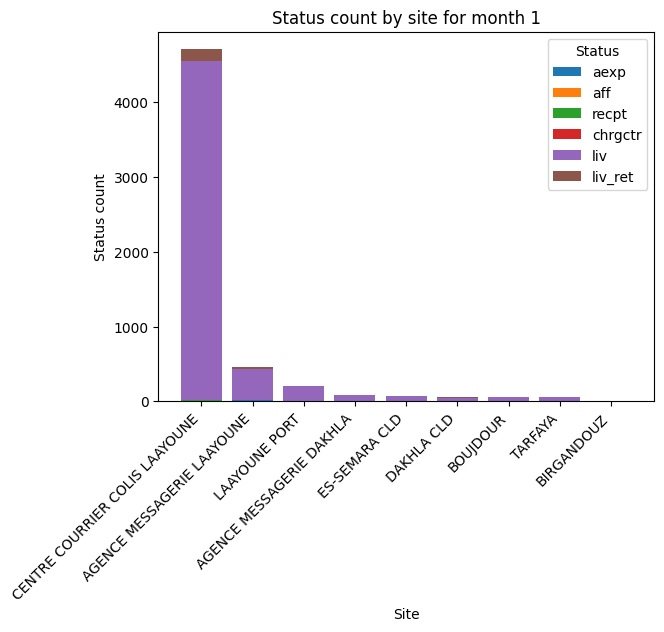

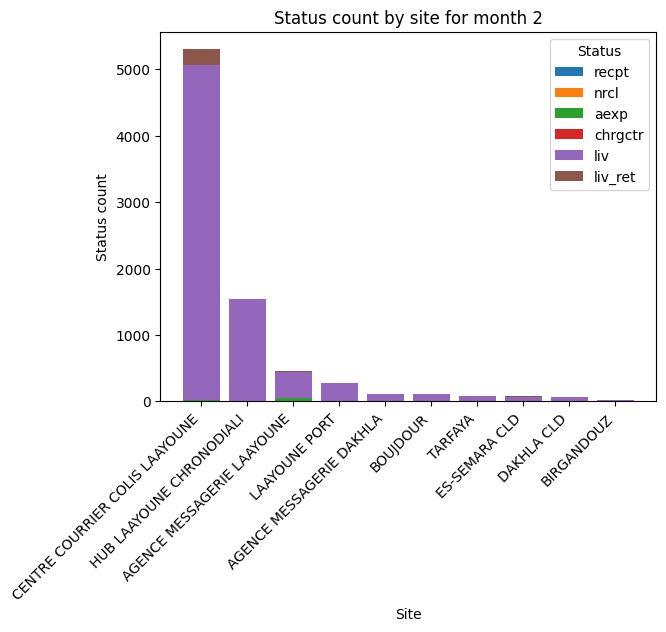

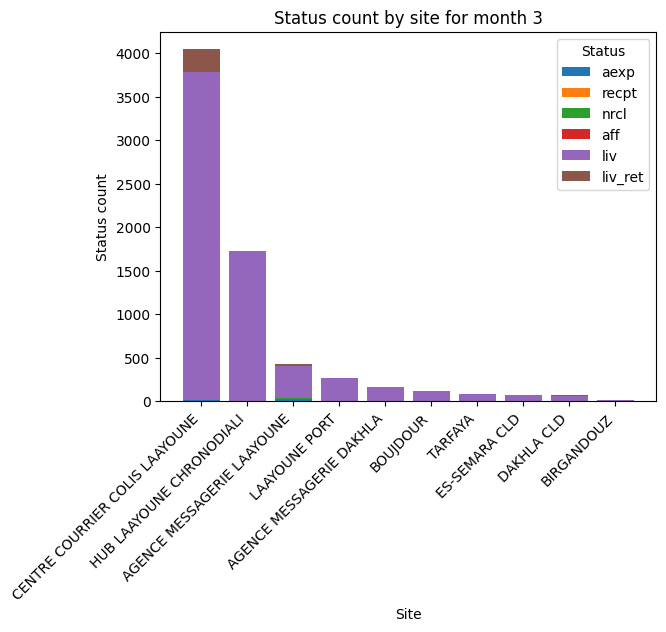

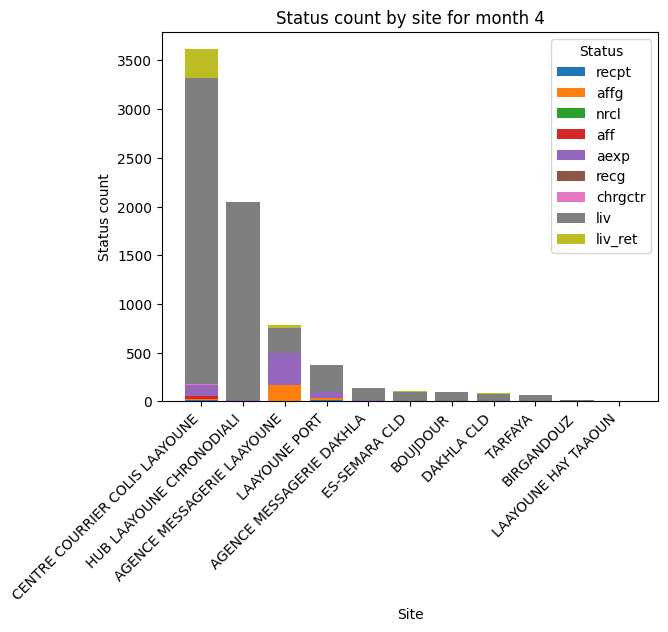

In [261]:
for (month,), month_data in months.items():
    pivot = build_pivot(month_data)
    pivot = sort_by_total(pivot)
    pivot = sort_columns_by_delivered(pivot)
    ax = plot_stacked(pivot)

    ax.set_ylabel("Status count")
    ax.set_title(f"Status count by site for month {month}")

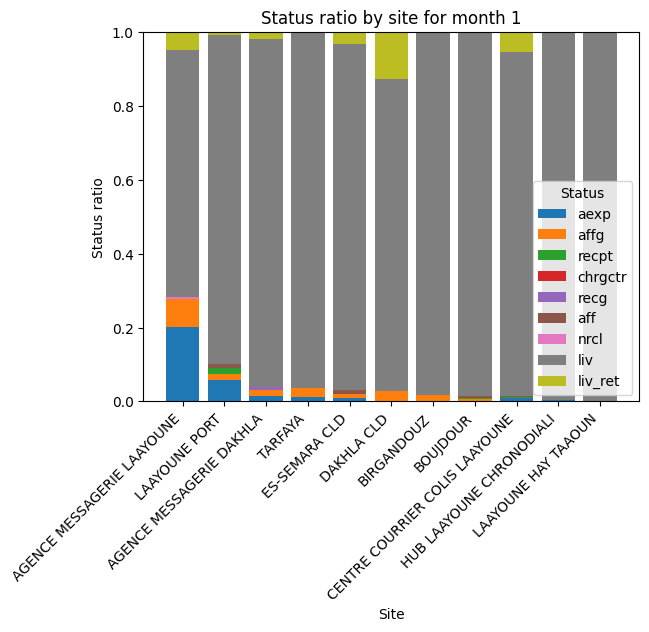

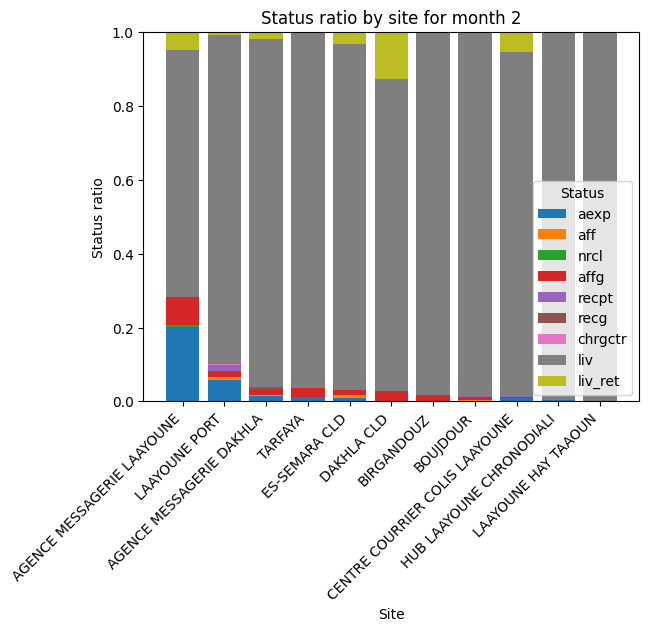

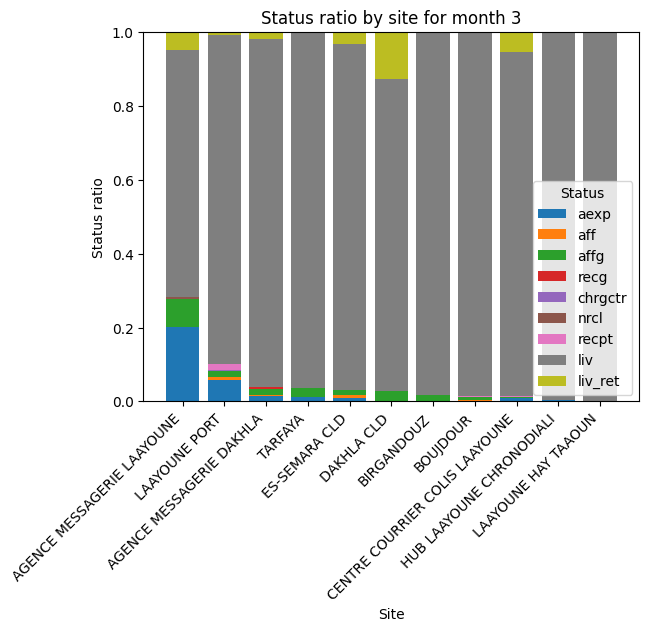

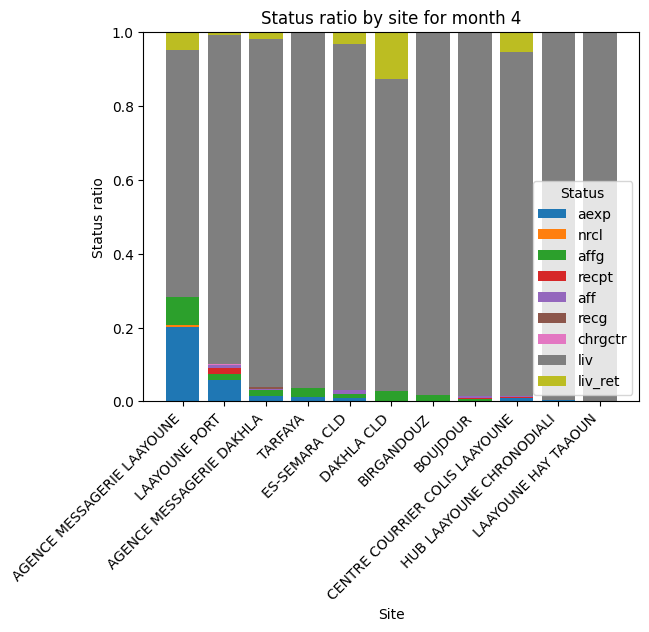

In [249]:
for (month,), month_data in months.items():
    pivot = build_pivot(data)
    pivot = normalize_rows(pivot)
    pivot = sort_by_subset(pivot, NOT_DELIVERED_STATUT_COLS)
    pivot = sort_columns_by_delivered(pivot)
    ax = plot_stacked(pivot)
    ax.set_ylabel("Status ratio")
    ax.set_title(f"Status ratio by site for month {month}")

In [235]:
for (month,), month_data in months.items():
    pivot = build_pivot(data)
    pivot = sort_by_subset(pivot, NOT_DELIVERED_STATUT_COLS)
    pivot = sort_columns_by_delivered(pivot)
    print(pivot)

shape: (11, 10)
┌────────────────────────────────┬─────┬──────┬──────┬──────┬─────────┬───────┬──────┬───────┬─────────┐
│ SITE DERNIER STATUT            ┆ aff ┆ aexp ┆ affg ┆ nrcl ┆ chrgctr ┆ recpt ┆ recg ┆ liv   ┆ liv_ret │
│ ---                            ┆ --- ┆ ---  ┆ ---  ┆ ---  ┆ ---     ┆ ---   ┆ ---  ┆ ---   ┆ ---     │
│ str                            ┆ u32 ┆ u32  ┆ u32  ┆ u32  ┆ u32     ┆ u32   ┆ u32  ┆ u32   ┆ u32     │
╞════════════════════════════════╪═════╪══════╪══════╪══════╪═════════╪═══════╪══════╪═══════╪═════════╡
│ AGENCE MESSAGERIE LAAYOUNE     ┆ 0   ┆ 429  ┆ 165  ┆ 11   ┆ 0       ┆ 0     ┆ 1    ┆ 1430  ┆ 105     │
│ CENTRE COURRIER COLIS LAAYOUNE ┆ 31  ┆ 151  ┆ 12   ┆ 2    ┆ 7       ┆ 42    ┆ 0    ┆ 16471 ┆ 943     │
│ LAAYOUNE PORT                  ┆ 10  ┆ 67   ┆ 17   ┆ 0    ┆ 3       ┆ 18    ┆ 0    ┆ 1019  ┆ 10      │
│ HUB LAAYOUNE CHRONODIALI       ┆ 3   ┆ 20   ┆ 0    ┆ 0    ┆ 0       ┆ 0     ┆ 0    ┆ 5296  ┆ 0       │
│ AGENCE MESSAGERIE DAKHLA       ┆ 1   

In [ ]:
for (month,), month_data in months.items():
    pivot = build_pivot(data)
    pivot = normalize_rows(pivot)
    pivot = sort_by_subset(pivot, NOT_DELIVERED_STATUT_COLS)
    pivot = pivot.select(
        pl.col("SITE DERNIER_STATUT"),
        pl.format("{} %", (ALL_STATUT_COLS * 100).round(2)),
    )
    pivot = sort_columns_by_delivered(pivot)
    print(pivot)

shape: (11, 10)
┌────────────────────────────────┬─────────┬────────┬────────┬─────────┬────────┬────────┬────────┬─────────┬─────────┐
│ SITE DERNIER STATUT            ┆ aexp    ┆ aff    ┆ affg   ┆ chrgctr ┆ nrcl   ┆ recg   ┆ recpt  ┆ liv     ┆ liv_ret │
│ ---                            ┆ ---     ┆ ---    ┆ ---    ┆ ---     ┆ ---    ┆ ---    ┆ ---    ┆ ---     ┆ ---     │
│ str                            ┆ str     ┆ str    ┆ str    ┆ str     ┆ str    ┆ str    ┆ str    ┆ str     ┆ str     │
╞════════════════════════════════╪═════════╪════════╪════════╪═════════╪════════╪════════╪════════╪═════════╪═════════╡
│ AGENCE MESSAGERIE LAAYOUNE     ┆ 20.04 % ┆ 0.0 %  ┆ 7.71 % ┆ 0.0 %   ┆ 0.51 % ┆ 0.05 % ┆ 0.0 %  ┆ 66.79 % ┆ 4.9 %   │
│ LAAYOUNE PORT                  ┆ 5.86 %  ┆ 0.87 % ┆ 1.49 % ┆ 0.26 %  ┆ 0.0 %  ┆ 0.0 %  ┆ 1.57 % ┆ 89.07 % ┆ 0.87 %  │
│ AGENCE MESSAGERIE DAKHLA       ┆ 1.6 %   ┆ 0.2 %  ┆ 1.6 %  ┆ 0.0 %   ┆ 0.0 %  ┆ 0.6 %  ┆ 0.0 %  ┆ 94.19 % ┆ 1.8 %   │
│ TARFAYA               